# Unsupervised Learning with K-Means and PCA

This is a starter notebook for the assignment, as outlined in the accompanying README file. Learners are expected to complete and deliver all their work for this portion of the assignment within this notebook.

In [1]:
# run this only once and then comment it out/delete the cell
! pip install ucimlrepo

# import the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# DATA LOADInG

In [3]:

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets# import the dataset



In [4]:
df = pd.concat([X, y], axis=1)

In [5]:
print(df)

     Channel  Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen  \
0          2  12669   9656     7561     214              2674        1338   
1          2   7057   9810     9568    1762              3293        1776   
2          2   6353   8808     7684    2405              3516        7844   
3          1  13265   1196     4221    6404               507        1788   
4          2  22615   5410     7198    3915              1777        5185   
..       ...    ...    ...      ...     ...               ...         ...   
435        1  29703  12051    16027   13135               182        2204   
436        1  39228   1431      764    4510                93        2346   
437        2  14531  15488    30243     437             14841        1867   
438        1  10290   1981     2232    1038               168        2125   
439        1   2787   1698     2510      65               477          52   

     Region  
0         3  
1         3  
2         3  
3         3  
4    

 # Exploratory Data Analysis (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   Region            440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [7]:
df.describe()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455,2.543182
std,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937,0.774272
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000,1.000000
25%,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000,2.000000
50%,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000,3.000000
75%,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000,3.000000
max,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000,3.000000


In [8]:
df.isnull().sum()

Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
Region              0
dtype: int64

EDA helps us understand the dataset structure, distributions, and relationships between variables before applying machine learning.

# Check how many duplicates exist

In [9]:
df.duplicated().sum()

np.int64(0)

The dataset was checked for duplicate records using the duplicated() function in pandas. No duplicate rows were found.

# Distribution of Features

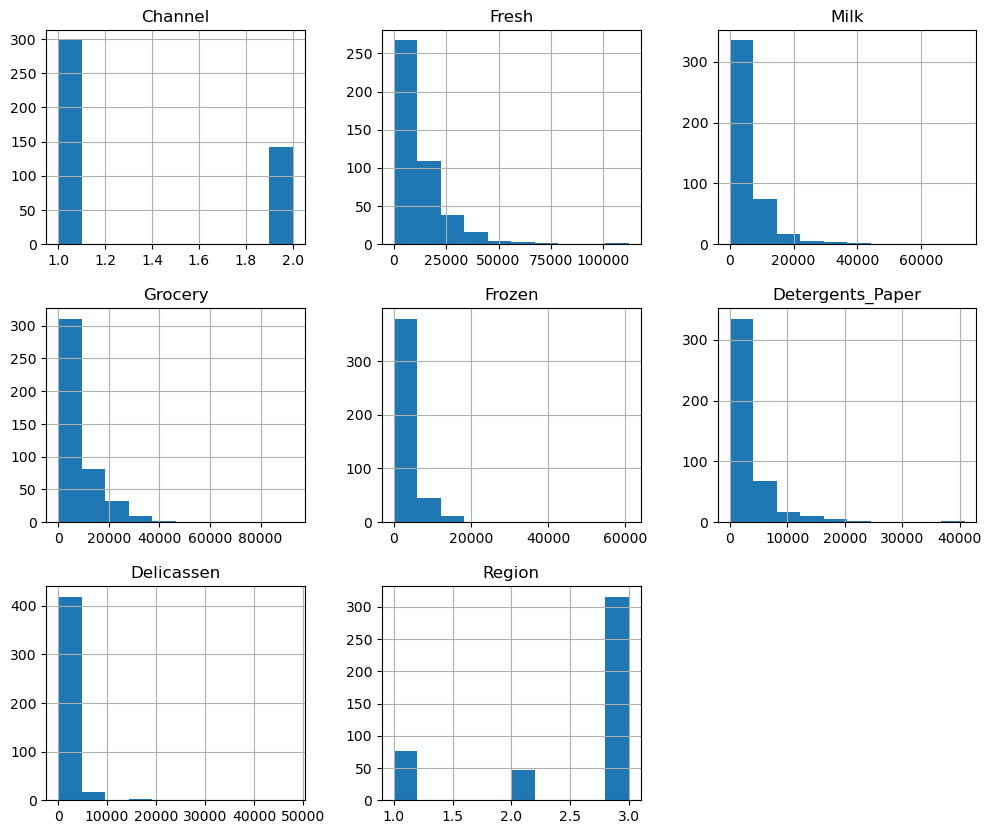

In [10]:
df.hist(figsize=(12,10))
plt.show()

Right-skewed means: Most values are small &
 few values are very large

Left Skewed means:Most values are large
&few values are very small

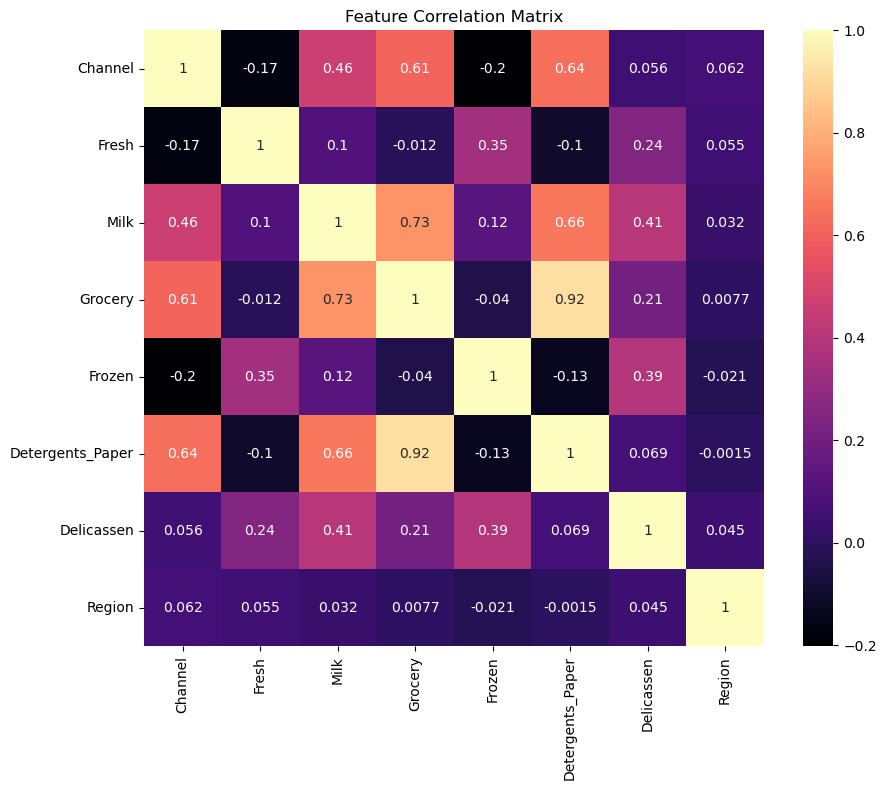

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="magma")
plt.title("Feature Correlation Matrix")
plt.show()

There is a strong relationship between Grocery, Milk, and Detergents_Paper. This means customers who buy one of these products often buy the others as well. This pattern may affect how customers are grouped during clustering.

 # Data Preparation

These columns (Channel and Region) are categories, not numbers.

If we include them in clustering, they can mess up the distance calculations.

So, we don’t use them for clustering, but we keep them to help understand and interpret the clusters later.

In [12]:
features = df.drop(columns=["Channel","Region"])

In [13]:
features.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


# Scale the Data

Scaling is important because PCA and KMeans depend on distance.

In [14]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_data, columns=features.columns)

scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


# Dimensionality Reduction (PCA)

In [15]:
pca = PCA()

pca_data = pca.fit_transform(scaled_df)

 # explained variance

We visualize explained variance to decide how many components to keep

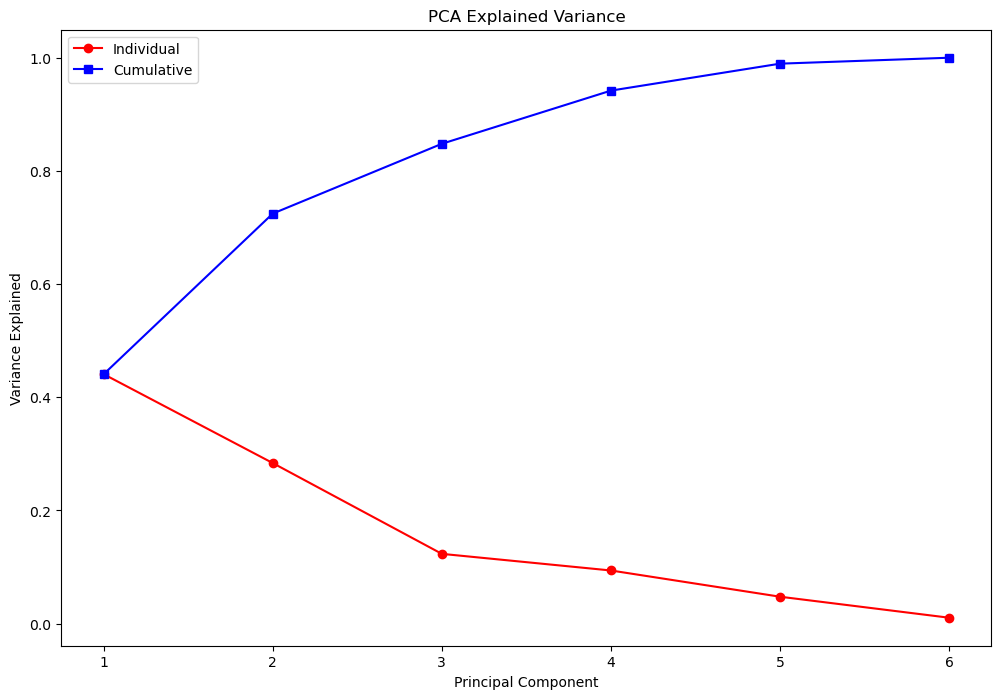

In [16]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12,8))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         color='red',
         label='Individual')
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='s',
         color='blue',
         label='Cumulative')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('PCA Explained Variance')
plt.legend()

plt.show()

In [17]:
pca = PCA(n_components=4)
pca_features = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_features, columns=['PC3','PC4','PC5','PC6'])
pca_df.head()

,PC3,PC4,PC5,PC6
0,0.193291,-0.305100,0.140878,-0.486432
1,0.434420,-0.328413,-0.319007,-0.178830
2,0.811143,0.815096,-1.523416,-1.254082
3,-0.778648,0.652754,-0.163012,0.380060
4,0.166287,1.271434,-0.066279,-0.826227


PCA was used to reduce the number of features. The last four principal components capture most of the data’s information, so we can use them for visualization and clustering.

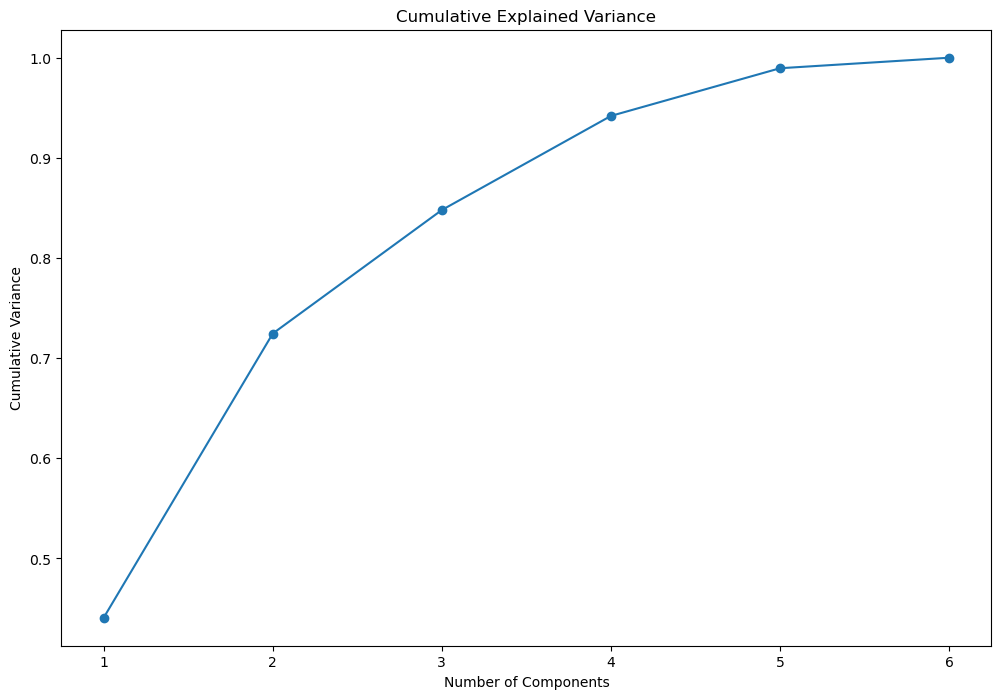

In [18]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12,8))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

# Clustering (KMeans)
Elbow Method

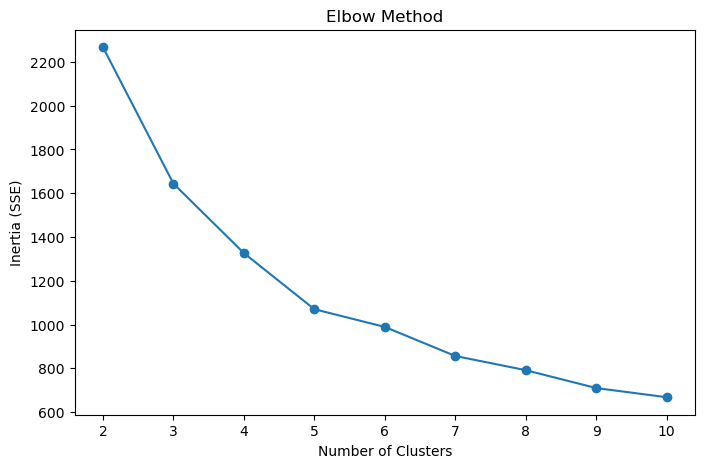

In [19]:
inertia = []

k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (SSE)")
plt.show()

The Elbow Method shows how the number of clusters (k) affects how tight the clusters are (inertia). The “elbow” is the point where adding more clusters doesn’t help much. Here, k = 3 looks best.

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_df)

df["Cluster"] = clusters

df.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,Cluster
0,2,12669,9656,7561,214,2674,1338,3,0
1,2,7057,9810,9568,1762,3293,1776,3,0
2,2,6353,8808,7684,2405,3516,7844,3,0
3,1,13265,1196,4221,6404,507,1788,3,0
4,2,22615,5410,7198,3915,1777,5185,3,1


# Compare Raw vs PCA Clustering

In [21]:
kmeans_raw = KMeans(n_clusters=3, random_state=42)
raw_labels = kmeans_raw.fit_predict(scaled_df)

sil_raw = silhouette_score(scaled_df, raw_labels)

sil_raw

0.4582633767207058

The silhouette score after PCA is 0.538, which means the clusters are fairly well separated. This shows that PCA kept the important patterns in the data and still allowed us to find meaningful customer groups.

In [22]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_labels = kmeans_pca.fit_predict(pca_df)

sil_pca = silhouette_score(pca_df, pca_labels)

sil_pca

0.5520221017448145

The silhouette score using PCA is 0.547, which is slightly higher than the raw data score of 0.538. This means PCA slightly improved the clustering results.

# Cluster Visualization

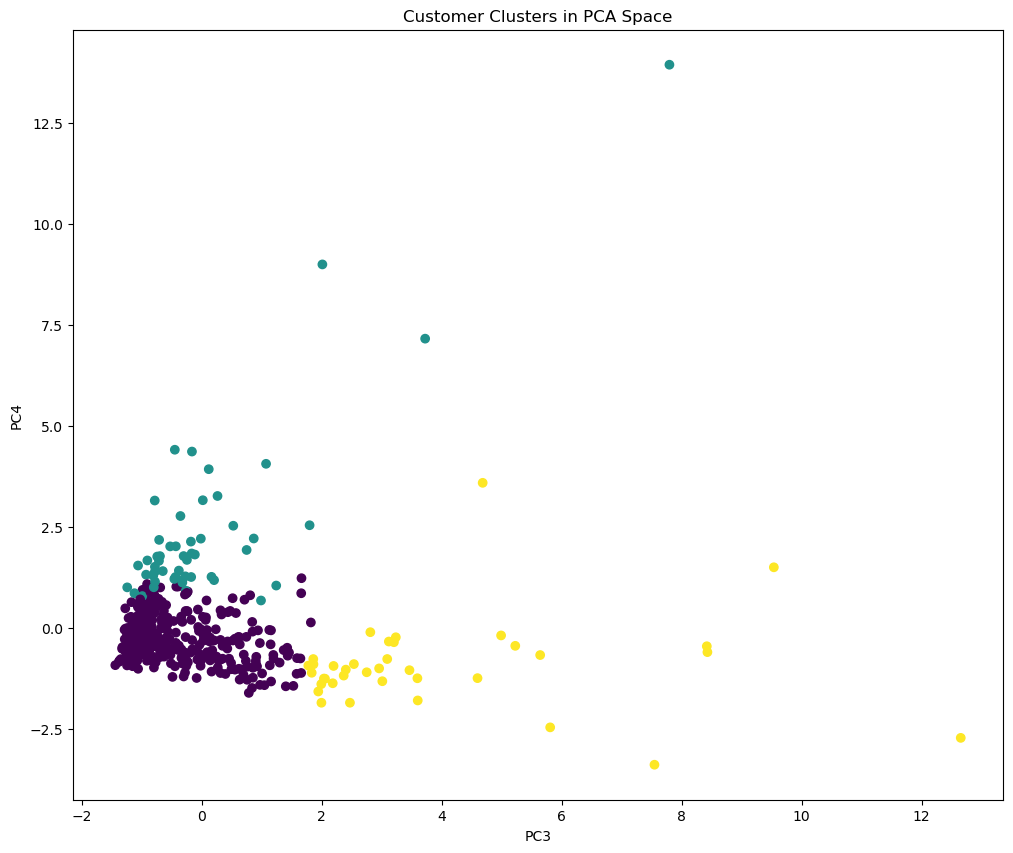

In [23]:
plt.figure(figsize=(12,10))

plt.scatter(pca_df["PC3"], pca_df["PC4"], c=clusters)

plt.xlabel("PC3")
plt.ylabel("PC4")
plt.title("Customer Clusters in PCA Space")

plt.show()